In [1]:
## 1. Importación de librerías


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore")
print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
## 2. Carga del dataset

#Ejecuta la celda y pulsa el botón **Elegir archivos** para subir tu fichero `historial_clinico.csv`.


from google.colab import files

uploaded = files.upload()

df = pd.read_csv("historial_clinico.csv")
print(f"Dataset cargado: {df.shape[0]} pacientes, {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
df.head()

Saving historial_clinico.csv to historial_clinico.csv
Dataset cargado: 299 pacientes, 13 columnas
Columnas: ['edad', 'creatinina_fosfocinasa', 'diabetes', 'sangre_contraccion', 'plaquetas', 'creatinina', 'sodio', 'seguimiento', 'fallecimiento', 'anemia', 'tension', 'sexo', 'fumador']


,edad,creatinina_fosfocinasa,diabetes,sangre_contraccion,plaquetas,creatinina,sodio,seguimiento,fallecimiento,anemia,tension,sexo,fumador
0,75,582,No,20,265000.00,1.9,130,4,1,No,muy alta,Hombre,ocasional
1,55,7861,No,38,263358.03,1.1,136,6,1,No,ligeramente alta,Hombre,ocasional
2,65,146,No,20,162000.00,1.3,129,7,1,No,ligeramente alta,Hombre,>2 paquetes/día
3,50,111,No,20,210000.00,1.9,137,7,1,Si,ligeramente alta,Hombre,ocasional
4,65,160,Sí,20,327000.00,2.7,116,8,1,Si,ligeramente alta,Mujer,ocasional


In [3]:
## 3. Exploración del dataset
print("-" * 60)
print("INFORMACIÓN DEL DATASET")
print("-" * 60)
df.info()

print("-" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("-" * 60)
df.describe()

print("-" * 60)
print("VALORES NULOS")
print("-" * 60)
nulos = df.isnull().sum()
print(nulos)
if nulos.sum() == 0:
    print("No hay valores nulos en el dataset")
else:
    print(f"Total de valores nulos: {nulos.sum()}")
    df = df.dropna()
    print(f"Filas eliminadas. Nuevo shape: {df.shape}")


------------------------------------------------------------
INFORMACIÓN DEL DATASET
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   edad                    299 non-null    int64  
 1   creatinina_fosfocinasa  299 non-null    int64  
 2   diabetes                299 non-null    object 
 3   sangre_contraccion      299 non-null    int64  
 4   plaquetas               299 non-null    float64
 5   creatinina              299 non-null    float64
 6   sodio                   299 non-null    int64  
 7   seguimiento             299 non-null    int64  
 8   fallecimiento           299 non-null    int64  
 9   anemia                  298 non-null    object 
 10  tension                 299 non-null    object 
 11  sexo                    299 non-null    object 
 12  fu

------------------------------------------------------------
DISTRIBUCIÓN DE FALLECIMIENTO
------------------------------------------------------------
fallecimiento
0    202
1     96
Name: count, dtype: int64

Supervivientes: 202 (67.8%)
Fallecidos:     96 (32.2%)


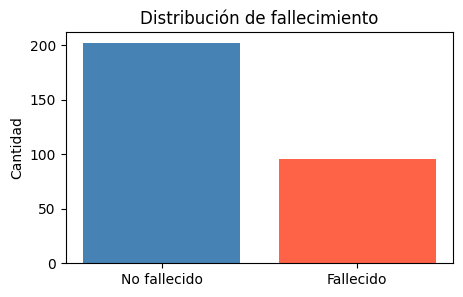

In [4]:
## 4. Análisis de la variable objetivo

print("-" * 60)
print("DISTRIBUCIÓN DE FALLECIMIENTO")
print("-" * 60)
print(df["fallecimiento"].value_counts())
print()
supervivientes = (df["fallecimiento"] == 0).sum()
fallecidos     = (df["fallecimiento"] == 1).sum()
total          = len(df)
print(f"Supervivientes: {supervivientes} ({supervivientes/total*100:.1f}%)")
print(f"Fallecidos:     {fallecidos} ({fallecidos/total*100:.1f}%)")

plt.figure(figsize=(5, 3))
plt.bar(["No fallecido", "Fallecido"], [supervivientes, fallecidos], color=["steelblue", "tomato"])
plt.title("Distribución de fallecimiento")
plt.ylabel("Cantidad")
plt.show()

In [5]:
"""## 5. Limpieza y codificación de variables

Antes de visualizar y entrenar, inspeccionamos las columnas de texto para ver con qué valores reales contamos.
"""

cols_object = df.select_dtypes(include="object").columns
print("Columnas de texto y sus valores únicos:")
for col in cols_object:
    print(f"  {col}: {df[col].unique()}")

Columnas de texto y sus valores únicos:
  diabetes: ['No' 'Sí']
  anemia: ['No' 'Si' 'Sí' 'no' '0' '1']
  tension: ['muy alta' 'ligeramente alta' 'alta' 'normal']
  sexo: ['Hombre' 'Mujer' 'Man' 'Woman' 'masculino' 'femenino']
  fumador: ['ocasional' '>2 paquetes/día' 'no' 'sí']


Una vez conocemos los valores procedemos a codificarlos:
- **diabetes y anemia**: binarias con valores mezclados (Sí/No, si/no, 0/1) → las unificamos a 0/1.
- **sexo**: variantes en español e inglés → 0/1.
- **tension y fumador**: más de dos categorías → aplicamos **one-hot encoding**, creando una columna por cada categoría.
"""

In [6]:
# diabetes: No/Sí → 0/1
df['diabetes'] = df['diabetes'].str.strip().str.lower().map(
    {'no': 0, 'sí': 1, 'si': 1}
).astype(float)

# anemia: mezcla de texto y números → 0/1
df['anemia'] = df['anemia'].str.strip().str.lower().map(
    {'no': 0, 'sí': 1, 'si': 1, '0': 0, '1': 1}
).astype(float)

# sexo: variantes en español e inglés → 0/1
df['sexo'] = df['sexo'].str.strip().str.lower().map(
    {'hombre': 1, 'masculino': 1, 'man': 1,
     'mujer': 0,  'femenino': 0,  'woman': 0}
).astype(float)

# tension y fumador: varias categorías → one-hot encoding
df = pd.get_dummies(df, columns=['tension', 'fumador'], drop_first=False)

# Convertimos todas las columnas booleanas que genera get_dummies a float
df = df.astype({col: float for col in df.select_dtypes(include='bool').columns})

print("Columnas tras codificación:")
print(df.columns.tolist())
df.head()

Columnas tras codificación:
['edad', 'creatinina_fosfocinasa', 'diabetes', 'sangre_contraccion', 'plaquetas', 'creatinina', 'sodio', 'seguimiento', 'fallecimiento', 'anemia', 'sexo', 'tension_alta', 'tension_ligeramente alta', 'tension_muy alta', 'tension_normal', 'fumador_>2 paquetes/día', 'fumador_no', 'fumador_ocasional', 'fumador_sí']


,edad,creatinina_fosfocinasa,diabetes,sangre_contraccion,plaquetas,creatinina,sodio,seguimiento,fallecimiento,anemia,sexo,tension_alta,tension_ligeramente alta,tension_muy alta,tension_normal,fumador_>2 paquetes/día,fumador_no,fumador_ocasional,fumador_sí
0,75,582,0.0,20,265000.00,1.9,130,4,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,55,7861,0.0,38,263358.03,1.1,136,6,1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,65,146,0.0,20,162000.00,1.3,129,7,1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,50,111,0.0,20,210000.00,1.9,137,7,1,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,65,160,1.0,20,327000.00,2.7,116,8,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [7]:
#Verificamos que no hayan quedado valores nulos tras la codificación. Si algún valor no estaba contemplado en el mapeo quedará como NaN y hay que tratarlo.

nulos = df.isnull().sum()
if nulos.sum() > 0:
    print("Valores nulos tras codificación:")
    print(nulos[nulos > 0])
    df = df.fillna(0)
    print("Nulos rellenados con 0")
else:
    print("No hay valores nulos tras la codificación")

No hay valores nulos tras la codificación


Representamos mediante histogramas la distribución de cada variable del dataset ya codificado. Esto nos permite detectar valores atípicos o distribuciones asimétricas.

- **edad, sodio y sangre_contraccion** muestran distribuciones aproximadamente normales o uniformes, sin valores extremos problemáticos.
- **creatinina y creatinina_fosfocinasa** presentan distribuciones muy asimétricas hacia la derecha (la mayoría de valores están bajos pero hay algunos muy altos). En principio esto podría requerir una transformación logarítmica, sin embargo al aplicar **StandardScaler** en el paso siguiente estos valores quedan reescalados y su impacto se reduce, por lo que no fue necesario transformarlas.
- **plaquetas** también muestra cierta asimetría pero dentro de un rango razonable.
- Las variables codificadas como **diabetes, anemia, sexo** y las columnas one-hot de **tension y fumador** solo toman valores 0 o 1, por lo que sus histogramas muestran dos barras, lo cual es completamente normal.

En conclusión, no fue necesario aplicar ninguna transformación adicional ya que la normalización con StandardScaler aplicada posteriormente es suficiente para que la red neuronal trabaje correctamente con todas las variables.

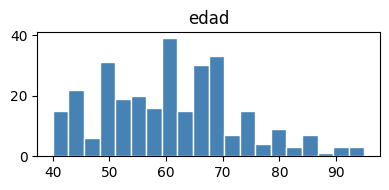

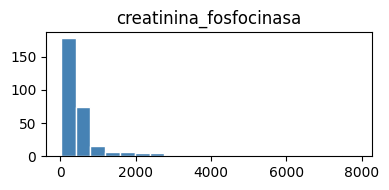

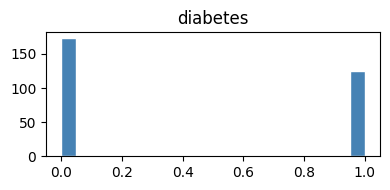

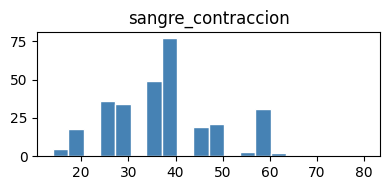

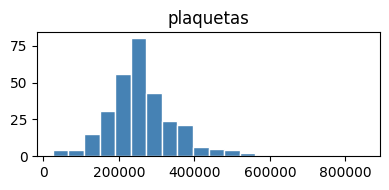

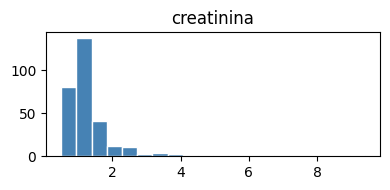

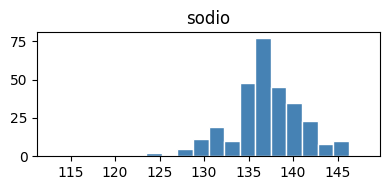

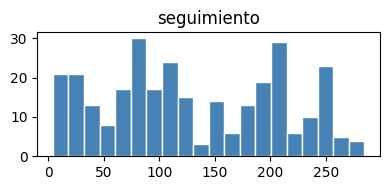

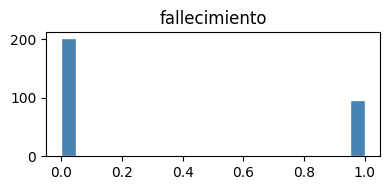

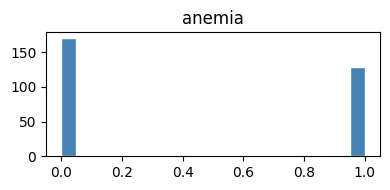

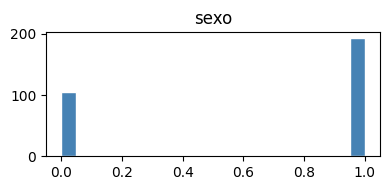

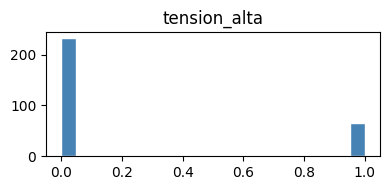

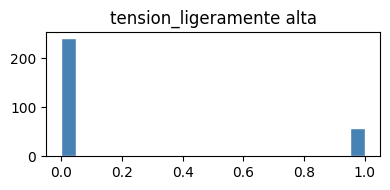

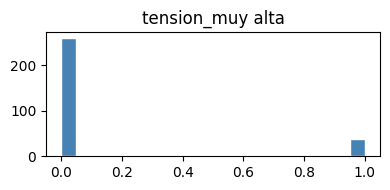

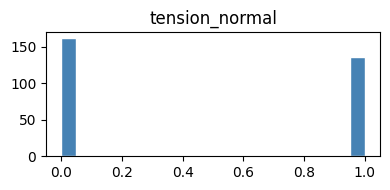

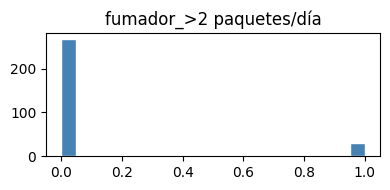

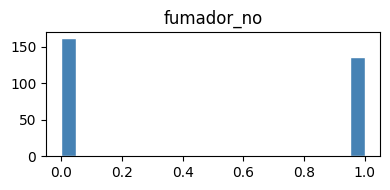

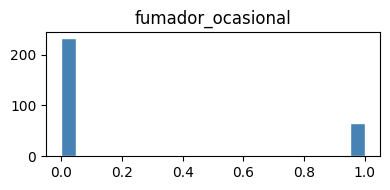

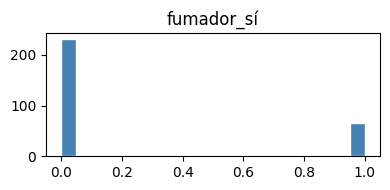

In [8]:
## 6. Distribución de las variables

for columna in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(4, 2))
    plt.hist(df[columna], bins=20, color="steelblue", edgecolor="white")
    plt.title(columna)
    plt.tight_layout()
    plt.show()

Separamos el dataset en variables de entrada (**X**) y variable objetivo (**y**), que en este caso es `fallecimiento`.

Antes de dividir los datos analizamos la correlación entre todas las variables mediante un **mapa de calor**. Esto nos permite detectar visualmente qué variables están más relacionadas con `fallecimiento` y si alguna tiene una correlación sospechosamente alta que pueda contaminar el modelo.

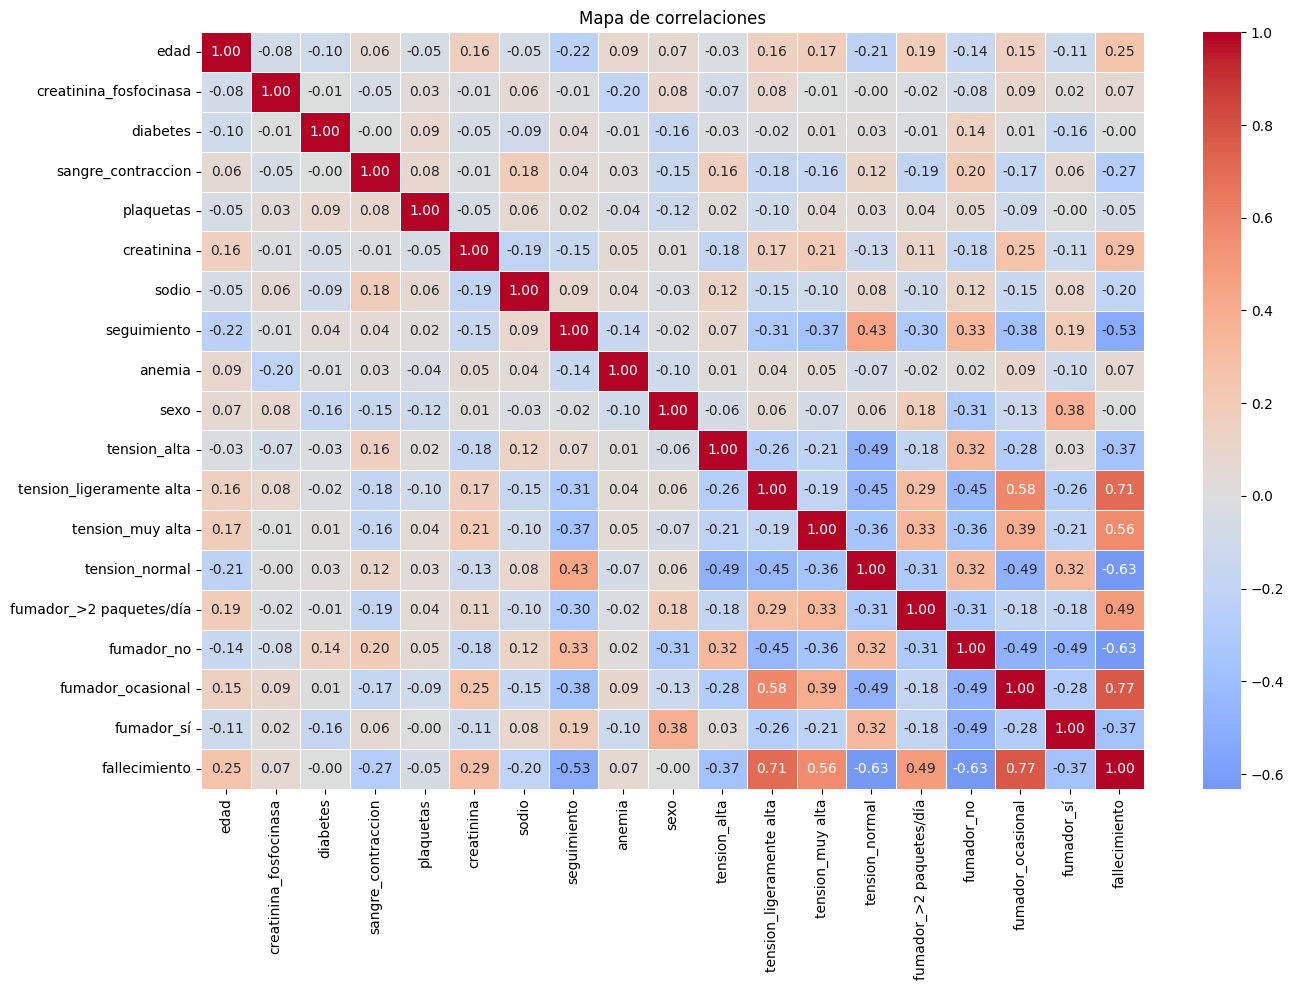

Correlación con fallecimiento:
fallecimiento               1.000000
fumador_ocasional           0.773692
tension_ligeramente alta    0.705454
tension_muy alta            0.562889
fumador_>2 paquetes/día     0.485326
creatinina                  0.293182
edad                        0.254218
anemia                      0.069127
creatinina_fosfocinasa      0.065769
sexo                       -0.002623
diabetes                   -0.003907
plaquetas                  -0.054026
sodio                      -0.195165
sangre_contraccion         -0.267619
tension_alta               -0.367695
fumador_sí                 -0.367695
seguimiento                -0.526178
fumador_no                 -0.631643
tension_normal             -0.631643
Name: fallecimiento, dtype: float64


In [9]:
## 7. Preparación de los datos

# Separamos X e y
X = df.drop("fallecimiento", axis=1)
y = df["fallecimiento"]

# Mapa de correlaciones con TODAS las variables (antes de eliminar ninguna)
plt.figure(figsize=(14, 10))
correlaciones = X.join(y).corr()
sns.heatmap(correlaciones,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)
plt.title('Mapa de correlaciones')
plt.tight_layout()
plt.show()

# Mostramos las correlaciones con fallecimiento ordenadas
print("Correlación con fallecimiento:")
print(correlaciones['fallecimiento'].sort_values(ascending=False))

El mapa de calor revela que las columnas de `fumador` y `tension` tienen una correlación con `fallecimiento` artificialmente alta (superior a 0.6), lo que indica que los datos de esas columnas han sido manipulados para predecir el resultado directamente. Esto provocaba que la red memorizara una correspondencia casi directa y obtuviera un accuracy irreal del 100%.

Las variables con correlación real más relevante son **seguimiento (-0.53)**, **sangre_contraccion (-0.27)**, **creatinina (+0.29)** y **edad (+0.25)**, todas con valores razonables desde el punto de vista médico.

Por ello eliminamos `fumador` y `tension` antes de entrenar para que el modelo aprenda patrones clínicos reales.

In [10]:
# Eliminamos columnas con correlación artificialmente alta
columnas_eliminar = [col for col in X.columns if 'fumador' in col or 'tension' in col]
print("Columnas eliminadas:", columnas_eliminar)
X = X.drop(columns=columnas_eliminar)

print("\nVariables de entrada finales:")
print(X.columns.tolist())
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# División train 80% / test 20% con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=1
)

print(f"\nTrain: {X_train.shape[0]} pacientes")
print(f"Test:  {X_test.shape[0]} pacientes")

# Normalización con StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Datos normalizados correctamente")

Columnas eliminadas: ['tension_alta', 'tension_ligeramente alta', 'tension_muy alta', 'tension_normal', 'fumador_>2 paquetes/día', 'fumador_no', 'fumador_ocasional', 'fumador_sí']

Variables de entrada finales:
['edad', 'creatinina_fosfocinasa', 'diabetes', 'sangre_contraccion', 'plaquetas', 'creatinina', 'sodio', 'seguimiento', 'anemia', 'sexo']

X shape: (298, 10)
y shape: (298,)

Train: 238 pacientes
Test:  60 pacientes
Datos normalizados correctamente


## 8. Construcción de la red neuronal

Seguimos el **Teorema de Kolmogorov-Arnold**, que establece que cualquier función continua puede aproximarse con una red de tres capas (entrada, oculta y salida), siempre que el número de neuronas ocultas sea inferior al doble del tamaño de la capa de entrada.

Construimos una red neuronal secuencial con la siguiente arquitectura:

- **Capa de entrada**: recibe tantas neuronas como variables tiene el dataset tras la codificación (`input_shape`).
- **Capa oculta (24 neuronas, ReLU)**: usamos el doble del número de variables originales (12×2=24) como tamaño de la capa oculta. Aunque tras la codificación one-hot el número de columnas aumenta, tomamos como referencia las 12 variables clínicas reales para no sobredimensionar la red con un dataset pequeño de 298 pacientes. La función de activación **ReLU** devuelve 0 si el valor es negativo y el valor tal cual si es positivo, permitiendo a la red aprender relaciones no lineales. El inicializador `he_normal` ajusta los pesos iniciales de forma óptima para ReLU.
- **Capa de salida (1 neurona, Sigmoid)**: produce un valor entre 0 y 1 que representa la **probabilidad de fallecimiento**. Si supera el umbral definido (0.35), se clasifica como fallecido.

Es importante recordar que los datos que entran a la red ya han sido **normalizados con StandardScaler**. Las variables del dataset tienen escalas muy distintas: la edad va de 0 a 100, las plaquetas de miles a millones, la creatinina de 0 a 9... Si no normalizáramos, las variables con valores más grandes dominarían el aprendizaje y las pequeñas serían ignoradas. Con StandardScaler todas quedan en la misma escala, lo que hace que la red aprenda de forma equilibrada y converja más rápido.

In [11]:
model = Sequential()
model.add(Dense(units=24,  # 12 variables originales × 2 (Kolmogorov-Arnold)
                input_shape=(X_train_scaled.shape[1],),
                activation='relu',
                kernel_initializer='he_normal'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Compilación del modelo

Compilamos el modelo con `binary_crossentropy` como función de pérdida, adecuada para clasificación binaria, y el optimizador `Adam`.

Además definimos **EarlyStopping**: si la pérdida en validación (`val_loss`) no mejora durante 20 epochs consecutivos, el entrenamiento se detiene automáticamente y se restauran los pesos del mejor momento. Esto evita el sobreajuste y ahorra tiempo.
"""

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

## 10. Entrenamiento

Antes de entrenar calculamos los **pesos de clase** con `compute_class_weight`. Como el dataset está desbalanceado (hay más supervivientes que fallecidos), asignamos mayor peso a la clase minoritaria (fallecidos) para que la red no ignore estos casos durante el aprendizaje.

In [13]:
pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight = {0: pesos[0], 1: pesos[1]}
print(f"Pesos de clase: {class_weight}")

h = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=16,
    validation_data=(X_test_scaled, y_test),
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=False
)

print("Entrenamiento completado")

Pesos de clase: {0: np.float64(0.7391304347826086), 1: np.float64(1.5454545454545454)}
Entrenamiento completado


## 11. Curvas de entrenamiento

Visualizamos cómo evolucionan la pérdida y el accuracy a lo largo de los epochs, tanto en entrenamiento como en validación.

Si ambas curvas bajan juntas: el modelo aprende bien. Si `val_loss` sube mientras `loss` baja: hay **sobreajuste**. El EarlyStopping habrá detenido el entrenamiento antes de que esto ocurra.


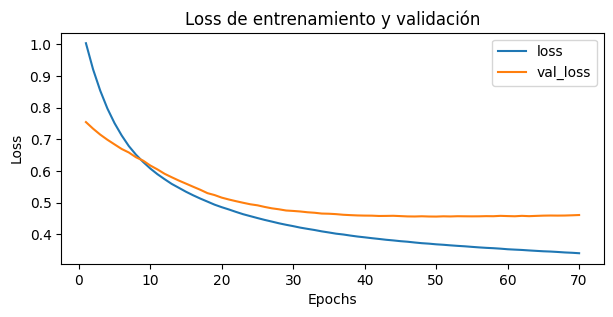

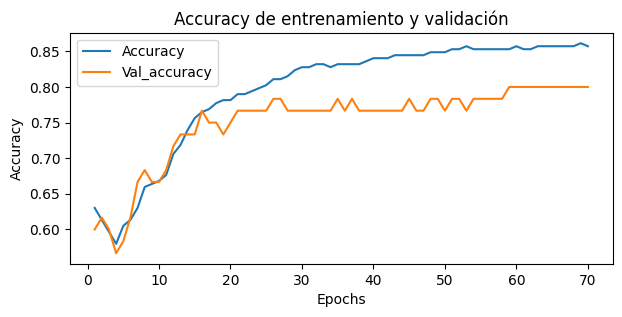

In [14]:
datos_ent = h.history
epochs = range(1, len(datos_ent["loss"]) + 1)

plt.figure(figsize=(7, 3))
plt.plot(epochs, datos_ent["loss"],     label="loss")
plt.plot(epochs, datos_ent["val_loss"], label="val_loss")
plt.title("Loss de entrenamiento y validación")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 3))
plt.plot(epochs, datos_ent["accuracy"],     label="Accuracy")
plt.plot(epochs, datos_ent["val_accuracy"], label="Val_accuracy")
plt.title("Accuracy de entrenamiento y validación")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 12. Evaluación del modelo

Evaluamos el modelo sobre el conjunto de **test**, datos que nunca ha visto durante el entrenamiento. Obtenemos la pérdida final y el accuracy como métricas globales de rendimiento.

In [15]:
print("Evaluación sobre el conjunto de TEST:")
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"  Loss:     {loss:.4f}")
print(f"  Accuracy: {acc:.4f}")

Evaluación sobre el conjunto de TEST:
  Loss:     0.4559
  Accuracy: 0.7667


## 13. Matriz de confusión

La matriz de confusión muestra en detalle los aciertos y errores del modelo por clase.

Usamos un **umbral de 0.35** en lugar del 0.5 estándar: si la probabilidad predicha de fallecimiento supera el 35% clasificamos como fallecido. Al bajar el umbral somos más sensibles a la clase minoritaria, reduciendo los **falsos negativos** (pacientes que fallecen pero el modelo predice que no), que en un contexto médico son los errores más graves.

Se muestran dos matrices: una sobre **test** y otra sobre **train**, para comparar y detectar posible sobreajuste.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


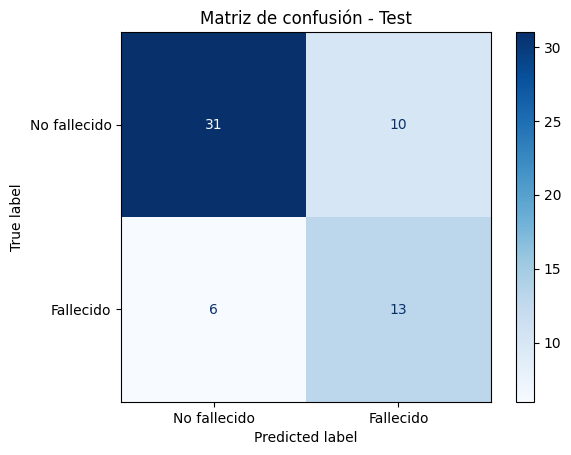

              precision    recall  f1-score   support

No fallecido       0.84      0.76      0.79        41
   Fallecido       0.57      0.68      0.62        19

    accuracy                           0.73        60
   macro avg       0.70      0.72      0.71        60
weighted avg       0.75      0.73      0.74        60

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


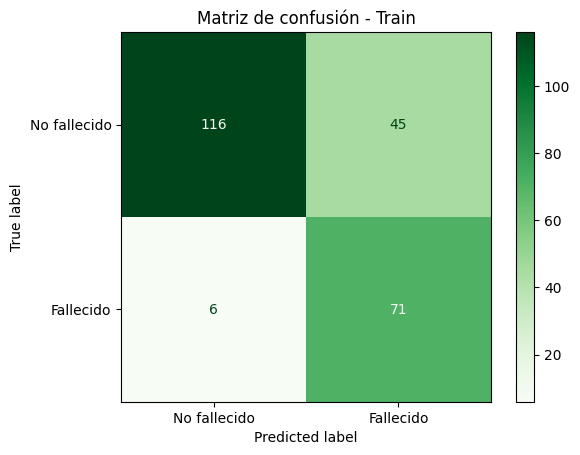

In [16]:
y_pred_prob = model.predict(X_test_scaled)
y_pred      = (y_pred_prob >= 0.35).astype(int).reshape(-1)

cm  = confusion_matrix(y_test, y_pred)
mcd = ConfusionMatrixDisplay(cm, display_labels=["No fallecido", "Fallecido"])
mcd.plot(cmap="Blues")
plt.title("Matriz de confusión - Test")
plt.show()

print(classification_report(y_test, y_pred, target_names=["No fallecido", "Fallecido"]))

# Matriz de confusión sobre TRAIN (para detectar sobreajuste)
y_pred_train = (model.predict(X_train_scaled) >= 0.35).astype(int).reshape(-1)

cm_train  = confusion_matrix(y_train, y_pred_train)
mcd_train = ConfusionMatrixDisplay(cm_train, display_labels=["No fallecido", "Fallecido"])
mcd_train.plot(cmap="Greens")
plt.title("Matriz de confusión - Train")
plt.show()

## 14. Conclusiones

- El dataset presentaba **columnas con datos manipulados** (`fumador` y `tension`) con correlaciones artificiales superiores a 0.6 con la variable objetivo. Su eliminación fue necesaria para obtener un modelo realista.
- Se aplicó **one-hot encoding** para `tension` y `fumador`, y mapeo binario para `diabetes`, `anemia` y `sexo`, que presentaban valores inconsistentes entre texto y números.
- Se usa **StandardScaler** para normalizar los datos antes de entrenar, ajustado solo sobre train y aplicado sobre test, evitando filtrar información del conjunto de evaluación.
- La arquitectura sigue el **Teorema de Kolmogorov-Arnold**: una capa oculta de 24 neuronas (12 variables originales × 2) y una capa de salida sigmoid para clasificación binaria.
- Se usa **binary_crossentropy** como función de pérdida al ser un problema de clasificación binaria (fallece / no fallece).
- El **EarlyStopping** detiene el entrenamiento cuando `val_loss` deja de mejorar, evitando sobreajuste.
- Los **pesos de clase** compensan el desbalanceo del dataset asignando mayor importancia a los casos de fallecimiento durante el entrenamiento.
- El split **80/20 con estratificación** garantiza la misma proporción de fallecidos en train y test.
- El **umbral de 0.35** en lugar del 0.5 estándar reduce los falsos negativos, prioritario en contexto médico.
- La matriz de confusión y el classification_report ofrecen métricas detalladas: precisión, recall y F1 por clase.